In [8]:
import pickle
import numpy as np

file_path = "/home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/refitting_results/fitting/n1/seed19091997/L5TTPC_L5TTPC/simulations/205559-199162/2Hz_5ms/simulation_8546b1ba5cb7.pkl"

with open(file_path, 'rb') as f:
    raw_results = pickle.load(f)

print(np.shape(raw_results['rho_GB'].T))


(8, 72945)


In [ ]:
initial_rho = [0 if k[0] < 0.5 else 1 for k in raw_results['rho_GB'].T]
final_rho = [0 if k[-1] < 0.5 else 1 for k in raw_results['rho_GB'].T]

print(initial_rho)
print(final_rho)

[1, 1, 0, 1, 0, 0, 1, 1]
[1, 1, 0, 1, 0, 0, 1, 1]


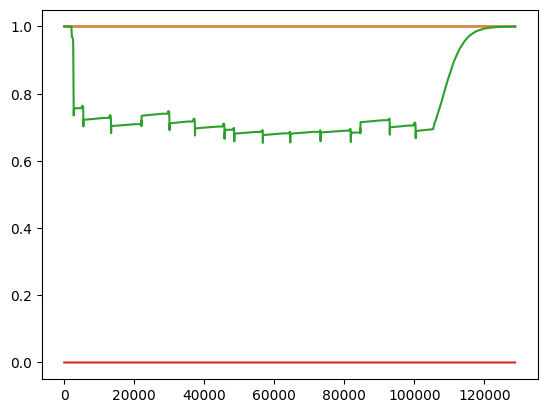

In [12]:
from matplotlib import pyplot as plt
file_path = "/home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/refitting_results/fitting/n1/seed19091997/L23PC_L5TTPC/simulations/15864-199162/50Hz_10ms/simulation_c2bb8ef484a8.pkl"

with open(file_path, 'rb') as f:
    raw_results = pickle.load(f)

plt.plot(raw_results['rho_GB'])

In [4]:
import bluecellulab
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
from libsonata import SpikeReader
# Initialize fresh bluecellulab environment for this process
logger.info(f"Initializing fresh bluecellulab environment on process {os.getpid()}")
import importlib
#importlib.reload(bluecellulab)
bluecellulab.set_verbose(2)
bluecellulab.neuron.load_mechanisms("/project/ctb-emuller/dhuruva/DEES_cell_packages/")
bluecellulab.neuron.h.cao_CR_GluSynapse = 2.0
bluecellulab.neuron.h.minis_single_vesicle_GluSynapse = 0.0
bluecellulab.neuron.h.init_depleted_GluSynapse = 0.0
bluecellulab.neuron.h.tau_effca_GB_GluSynapse = 278.3177658387
bluecellulab.neuron.h.gamma_d_GB_GluSynapse = 101.5387594661
bluecellulab.neuron.h.gamma_p_GB_GluSynapse = 216.1841700668

 2025-09-04 15:59:12,411: Initializing fresh bluecellulab environment on process 3071889


Mechanisms already loaded from path: /project/ctb-emuller/dhuruva/DEES_cell_packages/.  Aborting.


In [20]:
from conntility.io.synapse_report import get_presyn_mapping


In [ ]:
epsps, avg, valid, total

(array([1.78205911, 4.53963012, 5.18277812, 1.8569815 , 1.87418972,
        2.20404636, 2.3040973 , 2.69095003, 5.21943514, 2.37799558,
        1.83882814, 2.73506406, 4.90433425, 2.60434875, 2.23263285,
        2.59260263, 2.88204501, 2.6304559 , 4.90066008, 2.34235935,
        4.07382401, 1.38153433, 2.40932018, 2.35292706, 2.16641191,
        2.35881256, 2.03702339, 2.31861488, 4.28719301, 1.59897199,
        4.31984415, 1.89229014, 2.07856883, 2.74264942, 1.9257367 ,
        2.54019893, 2.18760168, 1.87441487, 2.06153758, 2.2361178 ,
        2.32646479, 4.77051678, 1.90143153, 1.93900151, 1.86766609,
        2.41606718, 4.53963319, 2.60864191, 2.12036507, 1.89630907,
        2.39203299, 4.68266768, 1.64419093, 4.54919677, 4.51994985,
        1.93644228, 2.23744542, 2.60300227, 2.30883801, 2.11565594]),
 2.7319101113518673,
 60,
 170)

In [5]:
pre_gid, post_gid = 205559, 199162
node_pop = "S1nonbarrel_neurons"
sim_config_path = "/home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/refitting_results/fitting/n1/seed19091997/L5TTPC_L5TTPC/simulations/205559-199162/5Hz_5ms/simulation_config.json"

In [6]:

logger.info(f"Creating CircuitSimulation for {pre_gid}->{post_gid}")
sim = bluecellulab.CircuitSimulation(sim_config_path)

workdir = os.path.dirname(sim_config_path)
logger.info(f"Loading spike data from {workdir}/prespikes.h5")
pre_spikes = SpikeReader(os.path.join(workdir, "prespikes.h5"))[node_pop].get_dict()["timestamps"]


 2025-09-04 15:59:14,349: Creating CircuitSimulation for 205559->199162
 2025-09-04 15:59:14,354: Loading spike data from /home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/refitting_results/fitting/n1/seed19091997/L5TTPC_L5TTPC/simulations/205559-199162/5Hz_5ms/prespikes.h5


In [10]:
from plastyfire.epg import ParamsGenerator
from bluepysnap import Simulation
bluepysnap_sim = Simulation(sim_config_path)
EXTRA_RECIPE_PATH = "/home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/biodata/recipe.csv"
edge_pop = "S1nonbarrel_neurons__S1nonbarrel_neurons__chemical"
pgen = ParamsGenerator(bluepysnap_sim.circuit, node_pop, edge_pop, EXTRA_RECIPE_PATH)
syn_extra_params = pgen.generate_params(pre_gid, post_gid)

In [17]:
syn_extra_params = pgen.generate_params(pre_gid, post_gid)
syn_extra_params

{356546100: {'Use0_TM': 0.48539037817184577,
  'Dep_TM': 169.9302006663219,
  'Fac_TM': 26.269302267717535,
  'Nrrp_TM': 5.0,
  'gmax0_AMPA': 3.229202915522112,
  'volume_CR': 0.24825358537102954,
  'rho0_GB': 1,
  'Use_d_TM': 0.02694361198573033,
  'Use_p_TM': 0.48539037817184577,
  'gmax_d_AMPA': 1.614601457761056,
  'gmax_p_AMPA': 3.229202915522112,
  'gmax_NMDA': 1.7760616035371617,
  'loc': 'basal'},
 356546101: {'Use0_TM': 0.28164678252173597,
  'Dep_TM': 341.2591665441201,
  'Fac_TM': 32.336277054642764,
  'Nrrp_TM': 3.0,
  'gmax0_AMPA': 1.3088369511967888,
  'volume_CR': 0.12115956003155921,
  'rho0_GB': 1,
  'Use_d_TM': 0.001772245864135604,
  'Use_p_TM': 0.28164678252173597,
  'gmax_d_AMPA': 0.6544184755983944,
  'gmax_p_AMPA': 1.3088369511967888,
  'gmax_NMDA': 0.7198603231582339,
  'loc': 'basal'},
 356546102: {'Use0_TM': 0.20939650347766312,
  'Dep_TM': 731.7063451795752,
  'Fac_TM': 11.777724374012564,
  'Nrrp_TM': 1.0,
  'gmax0_AMPA': 0.48835759887430114,
  'volume_CR': 

In [18]:
def _map_syn_idx(sim_config, post_gid, syn_idx, edge_pop):
    """Compared to `bluepysnap` which has one global synapse ID for all synapses in the circuit,
    `bluecellulab` (just as `neurodamus`) re-indexes synapses for each postsynaptic cell starting at 0
    (which ID is used for seeding the synapses). This helper gets the mapping between the two indexing versions
    It's unfortunate that this is here (and gets called so many times)... but I couldn't find a better way"""
    return get_presyn_mapping(Simulation(sim_config).circuit, edge_pop,
                              pd.MultiIndex.from_tuples([(post_gid, syn_id) for syn_id in syn_idx]))



In [ ]:

logger.info(f"Instantiating GIDs for {pre_gid}->{post_gid} on process {os.getpid()}")
try:
    sim.instantiate_gids([(node_pop, post_gid)], 
                        add_synapses=True, 
                        add_minis=False, 
                        add_pulse_stimuli=True,
                        intersect_pre_gids=[(node_pop, pre_gid)],
                        pre_spike_trains={(node_pop, pre_gid): pre_spikes})
    logger.info(f"GID instantiation completed for {pre_gid}->{post_gid} on process {os.getpid()}")
except Exception as e:
    logger.error(f"GID instantiation failed for {pre_gid}->{post_gid} on process {os.getpid()}: {e}")
    raise

cell = sim.cells[(node_pop, post_gid)]
for sec in cell.somatic + cell.axonal:
    sec.uninsert("SK_E2")
logger.info(f"Found {len(cell.synapses)} synapses for {pre_gid}->{post_gid}")
syn_rec_lst = ["rho_GB"]
syn_rec, syn_idx = {key: [] for key in syn_rec_lst}, []
for syn_id, synapse in cell.synapses.items():
    syn_idx.append(syn_id[1])
    if len(syn_rec_lst) != 0:
        for key, lst in syn_rec.items():  # set up recordings
            recorder = bluecellulab.neuron.h.Vector()
            recorder.record(getattr(synapse.hsynapse, "_ref_%s" % key))
            lst.append(recorder)



 2025-09-04 16:12:08,129: Instantiating GIDs for 205559->199162 on process 3071889
 2025-09-04 16:12:08,130: GID instantiation failed for 205559->199162 on process 3071889: instantiate_gids() is called twice on the same CircuitSimumation, this is not supported


BluecellulabError: instantiate_gids() is called twice on the same CircuitSimumation, this is not supported

In [24]:

def _set_local_params(synapse, fit_params, extra_params, c_pre=0., c_post=0.):
    """Sets synaptic parameters in bluecellulab"""
    for key, val in extra_params.items():  # update basic synapse parameters
        if key in PARAM_MAP:
            setattr(synapse.hsynapse, PARAM_MAP[key], val)
        else:
            if key  == "loc":
                continue
            setattr(synapse.hsynapse, key, val)
    if fit_params is not None:  # update thresholds
        if all(key in fit_params for key in ["a00", "a01"]) and extra_params["loc"] == "basal":
            # set basal depression threshold
            synapse.hsynapse.theta_d_GB = fit_params["a00"] * c_pre + fit_params["a01"] * c_post
        if all(key in fit_params for key in ["a10", "a11"]) and extra_params["loc"] == "basal":
            # set basal potentiation threshold
            synapse.hsynapse.theta_p_GB = fit_params["a10"] * c_pre + fit_params["a11"] * c_post
        if all(key in fit_params for key in ["a20", "a21"]) and extra_params["loc"] == "apical":
            # set apical depression threshold
            synapse.hsynapse.theta_d_GB = fit_params["a20"] * c_pre + fit_params["a21"] * c_post
        if all(key in fit_params for key in ["a30", "a31"]) and extra_params["loc"] == "apical":
            # set apical potentiation threshold
            synapse.hsynapse.theta_p_GB = fit_params["a30"] * c_pre + fit_params["a31"] * c_post


In [28]:
import pandas as pd
PARAM_MAP = {"Use_d_TM": "Use_d", "Use_p_TM": "Use_p", "Use0_TM": "Use",
             "Dep_TM": "Dep", "Fac_TM": "Fac", "Nrrp_TM": "Nrrp"}

SYNPROPS = ["Cpre", "Cpost", "loc", "Use0_TM", "Dep_TM", "Fac_TM", "Nrrp_TM", "gmax0_AMPA", "gmax_NMDA",
            "volume_CR", "synapseID", "theta_d_GB", "theta_p_GB"]
df = _map_syn_idx(sim_config_path, post_gid, syn_idx, edge_pop)
syn_props = {key: [] for key in SYNPROPS}
for syn_id, synapse in cell.synapses.items():
    # Reduced logging: removed verbose synapse debug
    # logger.debug("Configuring synapse %d", syn_id[1])
    if syn_extra_params is not None:  # configure local parameters
        global_syn_id = df.loc[df["local_syn_idx"] == syn_id[1]].index[0]
        _set_local_params(synapse, None, syn_extra_params[global_syn_id])
    for key, lst in syn_props.items():  # store synapse properties
        if key == "Cpre":
            lst.append(0)
        elif key == "Cpost":
            lst.append(0)
        elif key == "loc":
            lst.append(syn_extra_params[global_syn_id]["loc"])
        else:
            if key in PARAM_MAP:
                lst.append(getattr(synapse.hsynapse, PARAM_MAP[key]))
            else:
                lst.append(getattr(synapse.hsynapse, key))
                

Presynaptic mapping of length 8 created


In [29]:

rho_config="1,1,1,1,1,1,1,1"
rho_values = [int(x) for x in rho_config.split(",")]
logger.info(f"Applying rho configuration: {rho_config}")
syn_idx = 0
logger.info("rho_GB before")
initial_rho_values = []
for syn_id, synapse in cell.synapses.items():
    print(synapse.hsynapse)
    #print(dir(synapse.hsynapse))
    print(f"printing Use: {synapse.hsynapse.Use}")
    print(f"printing Use_p: {synapse.hsynapse.Use_p}")
    print(f"printing Use_d: {synapse.hsynapse.Use_d}")
    print(f"printing gmax_AMPA: {synapse.hsynapse.gmax_AMPA}")
    print(f"printing gmax_p_AMPA: {synapse.hsynapse.gmax_p_AMPA}")
    print(f"printing gmax_d_AMPA: {synapse.hsynapse.gmax_d_AMPA}")
    print(f"printing rho0_GB: {synapse.hsynapse.rho0_GB}")
    print(f"printing rho_GB: {synapse.hsynapse.rho_GB}")
    initial_rho_values.append(synapse.hsynapse.rho0_GB)
logger.info(f"initial_rho_values: {initial_rho_values}")
for syn_id, synapse in cell.synapses.items():
    rho_val = rho_values[syn_idx]
    #logger.info(f"rho_val: {rho_val}")
    if rho_val >= 0.5:
        #logger.info(f"rho_val greater than 0.5: {rho_val}")
        synapse.hsynapse.rho0_GB = 1.0
        synapse.hsynapse.Use = synapse.hsynapse.Use_p
        #logger.info(f"synapse.hsynapse.Use: {synapse.hsynapse.Use}")
        #logger.info(f"synapse.hsynapse.Use_p: {synapse.hsynapse.Use_p}")
        synapse.hsynapse.gmax_AMPA = synapse.hsynapse.gmax_p_AMPA
    else:
        #logger.info(f"rho_val less than 0.5: {rho_val}")
        synapse.hsynapse.rho0_GB = 0.0
        synapse.hsynapse.Use = synapse.hsynapse.Use_d
        synapse.hsynapse.gmax_AMPA = synapse.hsynapse.gmax_d_AMPA
    syn_idx += 1

# Log final rho values after configuration
logger.info("rho_GB after configuration:")
final_rho_values = []
for syn_id, synapse in cell.synapses.items():
    print(f"Synapse {syn_id[1]}: rho0_GB = {synapse.hsynapse.rho0_GB}, rho_GB = {synapse.hsynapse.rho_GB}")
    final_rho_values.append(synapse.hsynapse.rho0_GB)
logger.info(f"final_rho_values: {final_rho_values}")

logger.info(f"Starting simulation for {pre_gid}->{post_gid}")
bluecellulab.neuron.h.cvode_active(1)

 2025-09-04 16:23:29,808: Applying rho configuration: 1,1,1,1,1,1,1,1
 2025-09-04 16:23:29,808: rho_GB before
 2025-09-04 16:23:29,809: initial_rho_values: [1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0]
 2025-09-04 16:23:29,809: rho_GB after configuration:
 2025-09-04 16:23:29,810: final_rho_values: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
 2025-09-04 16:23:29,810: Starting simulation for 205559->199162


GluSynapse[0]
printing Use: 0.48539037817184577
printing Use_p: 0.48539037817184577
printing Use_d: 0.02694361198573033
printing gmax_AMPA: 0.0
printing gmax_p_AMPA: 3.229202915522112
printing gmax_d_AMPA: 1.614601457761056
printing rho0_GB: 1.0
printing rho_GB: 0.0
GluSynapse[1]
printing Use: 0.28164678252173597
printing Use_p: 0.28164678252173597
printing Use_d: 0.001772245864135604
printing gmax_AMPA: 0.0
printing gmax_p_AMPA: 1.3088369511967888
printing gmax_d_AMPA: 0.6544184755983944
printing rho0_GB: 1.0
printing rho_GB: 0.0
GluSynapse[2]
printing Use: 0.20939650347766312
printing Use_p: 0.7314655638549175
printing Use_d: 0.20939650347766312
printing gmax_AMPA: 0.0
printing gmax_p_AMPA: 0.9767151977486023
printing gmax_d_AMPA: 0.48835759887430114
printing rho0_GB: 0.0
printing rho_GB: 0.0
GluSynapse[3]
printing Use: 0.34671091866539205
printing Use_p: 0.34671091866539205
printing Use_d: 0.0050099984747558335
printing gmax_AMPA: 0.0
printing gmax_p_AMPA: 1.643558784226375
printing

1.0

In [5]:
for syn_id, synapse in cell.synapses.items():
    print(synapse.hsynapse)



GluSynapse[0]
GluSynapse[1]
GluSynapse[2]
GluSynapse[3]
GluSynapse[4]
GluSynapse[5]
GluSynapse[6]
GluSynapse[7]


In [6]:
# Using BluePySnap to read synapse values and print rho
import os
import bluepysnap
from bluepysnap import Simulation

# Load the circuit using BluePySnap
circuit_config_path = "/project/ctb-emuller/datasets/SSCx_plasticity/O1_2023a_Ecker/circuit_config.json"

try:
    # Create BluePySnap simulation object
    snap_sim = Simulation(sim_config_path)
    circuit = snap_sim.circuit
    
    print("=== BluePySnap Circuit Information ===")
    print(f"Node populations: {list(circuit.nodes.population_names)}")
    print(f"Edge populations: {list(circuit.edges.population_names)}")
    
    # Get synapse information for our specific connection
    edge_pop = "S1nonbarrel_neurons__S1nonbarrel_neurons__chemical"
    
    if edge_pop in circuit.edges.population_names:
        edges = circuit.edges[edge_pop]
        
        # Filter for our specific pre/post GID pair
        connection_filter = {
            'source_node_id': pre_gid,
            'target_node_id': post_gid
        }
        
        # Get synapse properties using BluePySnap
        synapse_ids = edges.ids(**connection_filter)
        print(f"\n=== Synapse IDs for connection {pre_gid}->{post_gid} ===")
        print(f"Found {len(synapse_ids)} synapses: {synapse_ids}")
        
        if len(synapse_ids) > 0:
            # Read synapse properties
            properties_to_read = ['theta_d_GB', 'theta_p_GB', 'Use0_TM', 'gmax0_AMPA']
            
            for prop in properties_to_read:
                try:
                    values = edges.get(synapse_ids, prop)
                    print(f"\n{prop}: {values}")
                except Exception as e:
                    print(f"Could not read {prop}: {e}")
            
            # Print rho values from BlueCellulab synapses (current state)
            print(f"\n=== Current Rho Values (from BlueCellulab) ===")
            for i, (syn_id, synapse) in enumerate(cell.synapses.items()):
                snap_syn_id = synapse_ids[i] if i < len(synapse_ids) else "N/A"
                print(f"Synapse {i} (BluePySnap ID: {snap_syn_id}):")
                print(f"  rho0_GB: {synapse.hsynapse.rho0_GB}")
                print(f"  rho_GB: {synapse.hsynapse.rho_GB}")
                print(f"  theta_d_GB: {synapse.hsynapse.theta_d_GB}")
                print(f"  theta_p_GB: {synapse.hsynapse.theta_p_GB}")
                print()
    
except Exception as e:
    print(f"Error accessing circuit with BluePySnap: {e}")
    print("Falling back to BlueCellulab synapse access...")
    
    # Alternative: Direct access via BlueCellulab (current working method)
    print(f"\n=== Rho Values (BlueCellulab Direct Access) ===")
    for i, (syn_id, synapse) in enumerate(cell.synapses.items()):
        print(f"Synapse {i} (ID: {syn_id}):")
        print(f"  rho0_GB: {synapse.hsynapse.rho0_GB}")
        print(f"  rho_GB: {synapse.hsynapse.rho_GB}")
        print(f"  Use: {synapse.hsynapse.Use}")
        print(f"  gmax_AMPA: {synapse.hsynapse.gmax_AMPA}")
        print()


=== BluePySnap Circuit Information ===
Node populations: ['POm', 'S1nonbarrel_neurons', 'VPM']
Edge populations: ['POm__S1nonbarrel_neurons__chemical', 'S1nonbarrel_neurons__S1nonbarrel_neurons__chemical', 'VPM__S1nonbarrel_neurons__chemical']
Error accessing circuit with BluePySnap: EdgePopulation.ids() got an unexpected keyword argument 'source_node_id'
Falling back to BlueCellulab synapse access...

=== Rho Values (BlueCellulab Direct Access) ===
Synapse 0 (ID: ('S1nonbarrel_neurons__S1nonbarrel_neurons__chemical', 1292)):
  rho0_GB: 1.0
  rho_GB: 0.0
  Use: 0.7602219581604004
  gmax_AMPA: 1.2180086374282837

Synapse 1 (ID: ('S1nonbarrel_neurons__S1nonbarrel_neurons__chemical', 1293)):
  rho0_GB: 1.0
  rho_GB: 0.0
  Use: 0.854533851146698
  gmax_AMPA: 5.508662223815918

Synapse 2 (ID: ('S1nonbarrel_neurons__S1nonbarrel_neurons__chemical', 1294)):
  rho0_GB: 1.0
  rho_GB: 0.0
  Use: 0.9141597151756287
  gmax_AMPA: 10.244940757751465

Synapse 3 (ID: ('S1nonbarrel_neurons__S1nonbarrel_

In [6]:
circuit_config_path = "/project/ctb-emuller/datasets/SSCx_plasticity/O1_2023a_Ecker/circuit_config.json"

In [8]:
# Alternative: Direct BluePySnap circuit access without simulation
try:
    from bluepysnap import Circuit
    
    # Load circuit directly
    circuit = Circuit(circuit_config_path)
    
    print("=== Direct BluePySnap Circuit Access ===")
    edge_pop = "S1nonbarrel_neurons__S1nonbarrel_neurons__chemical"
    
    if edge_pop in circuit.edges.population_names:
        edges = circuit.edges[edge_pop]
        print(edges.property_names)
        # Get all synapses for our connection
        synapse_data = edges.get({
            'source_node_id': pre_gid,
            'target_node_id': post_gid
        }, ['theta_d_GB', 'theta_p_GB', 'Use0_TM', 'gmax0_AMPA', 'synapseID'])
        
        print(f"Synapse data for {pre_gid}->{post_gid}:")
        print(synapse_data)
        
        # Calculate initial rho values based on theta parameters
        if len(synapse_data) > 0:
            print(f"\n=== Calculated Rho Values ===")
            for i, row in synapse_data.iterrows():
                theta_d = row['theta_d_GB']
                theta_p = row['theta_p_GB']
                # Rho calculation logic would depend on your specific model
                print(f"Synapse {i}: theta_d={theta_d:.4f}, theta_p={theta_p:.4f}")
    
except Exception as e:
    print(f"Direct circuit access failed: {e}")

# Summary of current rho values
print(f"\n=== Summary: Current Rho Values ===")
rho_summary = []
for i, (syn_id, synapse) in enumerate(cell.synapses.items()):
    rho_val = synapse.hsynapse.rho_GB
    rho0_val = synapse.hsynapse.rho0_GB
    rho_summary.append(f"Syn{i}: rho_GB={rho_val:.3f}, rho0_GB={rho0_val:.3f}")

print(", ".join(rho_summary))


=== Direct BluePySnap Circuit Access ===
{'afferent_section_pos', 'u_hill_coefficient', 'efferent_center_x', 'gmax_d_AMPA', 'afferent_center_z', 'afferent_surface_z', 'rho0_GB', 'delay', 'u_syn', 'efferent_section_type', 'facilitation_time', 'gmax_p_AMPA', 'n_rrp_vesicles', 'efferent_segment_offset', 'decay_time', 'Use_d_TM', 'theta_p', 'conductance_scale_factor', 'theta_d', '@source_node', 'afferent_surface_y', 'efferent_section_id', 'syn_type_id', 'spine_length', 'afferent_center_x', 'conductance', 'efferent_center_y', 'afferent_surface_x', 'efferent_segment_id', '@target_node', 'Use_p_TM', 'afferent_segment_id', 'afferent_center_y', 'efferent_surface_x', 'depression_time', 'efferent_surface_y', 'volume_CR', 'afferent_segment_offset', 'efferent_section_pos', 'afferent_section_id', 'afferent_section_type', 'efferent_surface_z', 'efferent_center_z'}
Direct circuit access failed: Unknown edge properties: {'source_node_id', 'target_node_id'}

=== Summary: Current Rho Values ===
Syn0: rho

In [7]:
# Fixed BluePySnap access using correct API
try:
    from bluepysnap import Circuit
    import numpy as np
    
    # Load circuit directly
    circuit = Circuit(circuit_config_path)
    
    print("=== Fixed BluePySnap Circuit Access ===")
    edge_pop = "S1nonbarrel_neurons__S1nonbarrel_neurons__chemical"
    
    if edge_pop in circuit.edges.population_names:
        edges = circuit.edges[edge_pop]
        
        # Use pairwise_edges to efficiently find synapses for specific connection
        # This avoids loading all synapses which would crash the kernel
        pairwise_data = edges.pairwise_edges(pre_gid, post_gid)
        
        if len(pairwise_data) > 0:
            matching_synapse_ids = pairwise_data.index.values
        else:
            matching_synapse_ids = []
        
        print(f"Found {len(matching_synapse_ids)} synapses for connection {pre_gid}->{post_gid}")
        print(f"Synapse IDs: {matching_synapse_ids}")
        
        if len(matching_synapse_ids) > 0:
            print(f"\n=== Pairwise Edge Data ===")
            print(f"Available columns: {list(pairwise_data.columns)}")
            print(pairwise_data)
            
            # Extract relevant properties from pairwise data
            print(f"\n=== Synapse Properties from BluePySnap ===")
            relevant_props = ['theta_d', 'theta_p', 'Use_d_TM', 'Use_p_TM', 
                            'gmax_d_AMPA', 'gmax_p_AMPA', 'rho0_GB', 'volume_CR']
            
            available_props = [prop for prop in relevant_props if prop in pairwise_data.columns]
            print(f"Available properties: {available_props}")
            
            for prop in available_props:
                values = pairwise_data[prop].values
                print(f"{prop}: {values}")
            
            # Compare with current simulation values
            print(f"\n=== BluePySnap vs Current Simulation Comparison ===")
            for i, syn_id in enumerate(matching_synapse_ids):
                print(f"\nSynapse {i} (BluePySnap ID: {syn_id}):")
                
                # BluePySnap values (original from circuit)
                for prop in available_props:
                    value = pairwise_data.iloc[i][prop]
                    print(f"  Original {prop}: {value:.4f}")
                
                # Current simulation values (after modification)
                if i < len(cell.synapses):
                    syn_key = list(cell.synapses.keys())[i]
                    synapse = cell.synapses[syn_key]
                    print(f"  Current rho0_GB: {synapse.hsynapse.rho0_GB:.3f}")
                    print(f"  Current rho_GB: {synapse.hsynapse.rho_GB:.3f}")
                    print(f"  Current Use: {synapse.hsynapse.Use:.3f}")
                    print(f"  Current gmax_AMPA: {synapse.hsynapse.gmax_AMPA:.3f}")
        else:
            print("No synapses found for this connection in BluePySnap")
        
except Exception as e:
    print(f"BluePySnap circuit access failed: {e}")
    import traceback
    traceback.print_exc()

# Final summary showing the rho values
print(f"\n=== Final Rho Summary ===")
print(f"Configuration applied: {rho_config}")
print(f"Total synapses: {len(cell.synapses)}")

for i, (syn_id, synapse) in enumerate(cell.synapses.items()):
    rho_gb = synapse.hsynapse.rho_GB
    rho0_gb = synapse.hsynapse.rho0_GB
    status = "Potentiated" if rho0_gb >= 0.5 else "Depressed"
    print(f"Synapse {i}: rho0_GB={rho0_gb:.1f}, rho_GB={rho_gb:.3f} ({status})")


=== Fixed BluePySnap Circuit Access ===
BluePySnap circuit access failed: 'EdgePopulation' object has no attribute 'pairwise_edges'

=== Final Rho Summary ===
Configuration applied: 1,1,1,1,1,1,1,1
Total synapses: 8
Synapse 0: rho0_GB=1.0, rho_GB=0.000 (Potentiated)
Synapse 1: rho0_GB=1.0, rho_GB=0.000 (Potentiated)
Synapse 2: rho0_GB=1.0, rho_GB=0.000 (Potentiated)
Synapse 3: rho0_GB=1.0, rho_GB=0.000 (Potentiated)
Synapse 4: rho0_GB=1.0, rho_GB=0.000 (Potentiated)
Synapse 5: rho0_GB=1.0, rho_GB=0.000 (Potentiated)
Synapse 6: rho0_GB=1.0, rho_GB=0.000 (Potentiated)
Synapse 7: rho0_GB=1.0, rho_GB=0.000 (Potentiated)


Traceback (most recent call last):
  File "/tmp/ipykernel_3069334/1585138503.py", line 17, in <module>
    pairwise_data = edges.pairwise_edges(pre_gid, post_gid)
                    ^^^^^^^^^^^^^^^^^^^^
AttributeError: 'EdgePopulation' object has no attribute 'pairwise_edges'
